# 베이지안 신경망을 이용한 임금–연령 프로파일의 비선형 추정과 불확실성 정량화

**베이지안 기계학습 기말 보고서**

---

## 초록 (Abstract)

전통적 신경망은 최대가능도(MLE)로 가중치를 단일 값으로 추정하므로 예측의 불확실성을 표현하지 못한다.
본 보고서는 미국 임금 자료(ISLR `Wage`, n=3,000)의 대표적 비선형 관계인 **연령–임금 프로파일(역U자)** 을
대상으로 (1) 일반 신경망(MLE)과 (2) **베이지안 신경망(BNN)** 을 비교한다. 두 모형의 평균 예측 정확도
(test RMSE)는 약 40으로 유사했으나, **불확실성의 표현에서 결정적 차이**가 나타났다. BNN은 데이터가 풍부한
중년층에서 좁고 희박한 청년·고령층에서 넓은 신용구간을 자동으로 부여하여, "모르는 곳에서 모른다고 말하는"
베이지안 추론의 본질을 보였다. 추가로 직군(jobclass)별로 나누어 같은 분석을 반복하였다.

## 1. 서론

### 1.1 연구 동기

신경망(MLP)은 임의의 매끄러운 함수를 근사할 수 있는 강력한 도구이지만, 표준적 학습은 손실을 최소화하는
**하나의 가중치 집합**만 찾는다(MLE). 데이터를 똑같이 잘 설명하는 다른 가중치 조합의 가능성은 버려지며,
그 결과 예측의 신뢰도를 정량화할 수 없다. 베이지안 신경망(BNN)은 가중치 $w$ 에 사전분포 $p(w)$ 를 부여하고
사후분포 $p(w \mid \mathcal{D})$ 를 추론하여, 예측과 **불확실성의 정량화**를 동시에 달성한다.

### 1.2 분석 대상

노동경제학에서 임금은 연령(경력)에 따라 상승하다 정점 후 완만해지는 **역U자(concave)** 프로파일을 보인다.
선형모형으로 포착 불가능한 이 구조는 신경망이 자동 학습하기에 적합하다. 또한 표본이 중년층에 집중되고
청년·고령층은 희박하므로, **불확실성이 연령 구간에 따라 어떻게 달라지는지**를 보여주기에 이상적인 사례다.

## 2. 데이터 및 환경

ISLR `Wage` 자료(3,000명)에서 종속변수는 임금(`wage`), 설명변수는 연령(`age`)을 사용한다.
분석 환경은 Python(NumPyro·JAX, PyTorch, pandas, matplotlib)이며, 한글 폰트와 시각화 테마를 설정한다.

In [1]:
from ISLP import load_data

Wage = load_data("Wage")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 테마 & 한글 폰트
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

## 3. 탐색적 자료 분석 (EDA)

### 3.1 연령–임금 관계

전체 및 직군별로 연령에 따른 임금의 추세(연령대별 평균선)를 함께 본다.

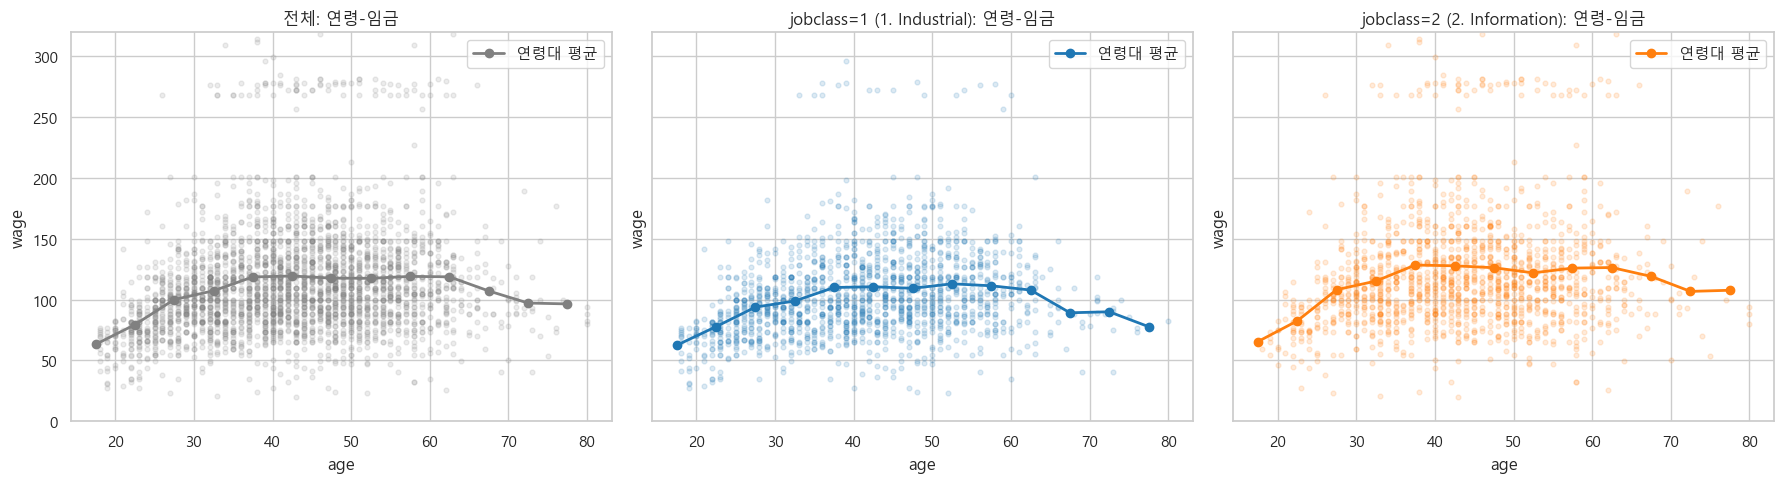

In [3]:
# Wage 데이터 탐색적 분석
# (참고) 실제 데이터: jobclass=1 -> "1. Industrial"(산업), jobclass=2 -> "2. Information"(정보)

bins = list(range(15, 85, 5))

def age_wage_panel(ax, data, title, color):
    """연령-임금 산점도 + 연령대별 평균임금 추세선"""
    ax.scatter(data["age"], data["wage"], s=12, alpha=0.15, color=color)
    grp = data.groupby(pd.cut(data["age"], bins=bins), observed=True)["wage"].mean()
    centers = [iv.mid for iv in grp.index]
    ax.plot(centers, grp.values, "o-", color=color, lw=2, label="연령대 평균")
    ax.set_title(title); ax.set_xlabel("age"); ax.set_ylabel("wage")
    ax.set_ylim(0, 320); ax.legend()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

## 연령-임금
age_wage_panel(axes[0], Wage, "전체: 연령-임금", "gray")

## jobclass=1 : 정보산업 종사자 의 연령-임금 관계
job1 = Wage[Wage["jobclass"] == "1. Industrial"]
age_wage_panel(axes[1], job1, "jobclass=1 (1. Industrial): 연령-임금", "tab:blue")

## jobclass=2 : 서비스업 종사자 의 연령-임금 관계
job2 = Wage[Wage["jobclass"] == "2. Information"]
age_wage_panel(axes[2], job2, "jobclass=2 (2. Information): 연령-임금", "tab:orange")

plt.tight_layout(); plt.show()

연령대별 평균임금은 18세 부근에서 시작해 **40대 중반에 정점(약 119)** 에 이른 뒤 완만해지는 전형적
**역U자**다. 70대 이후에는 평균이 다소 낮아지나, 이는 표본이 매우 적은 구간이라 변동이 크다.
직군으로 나누어 보아도 상승–정체의 큰 흐름은 유사하다.

### 3.2 연령대별 표본 수

불확실성 해석의 배경으로, 각 연령대(5세 구간)에 데이터가 얼마나 분포하는지 확인한다.

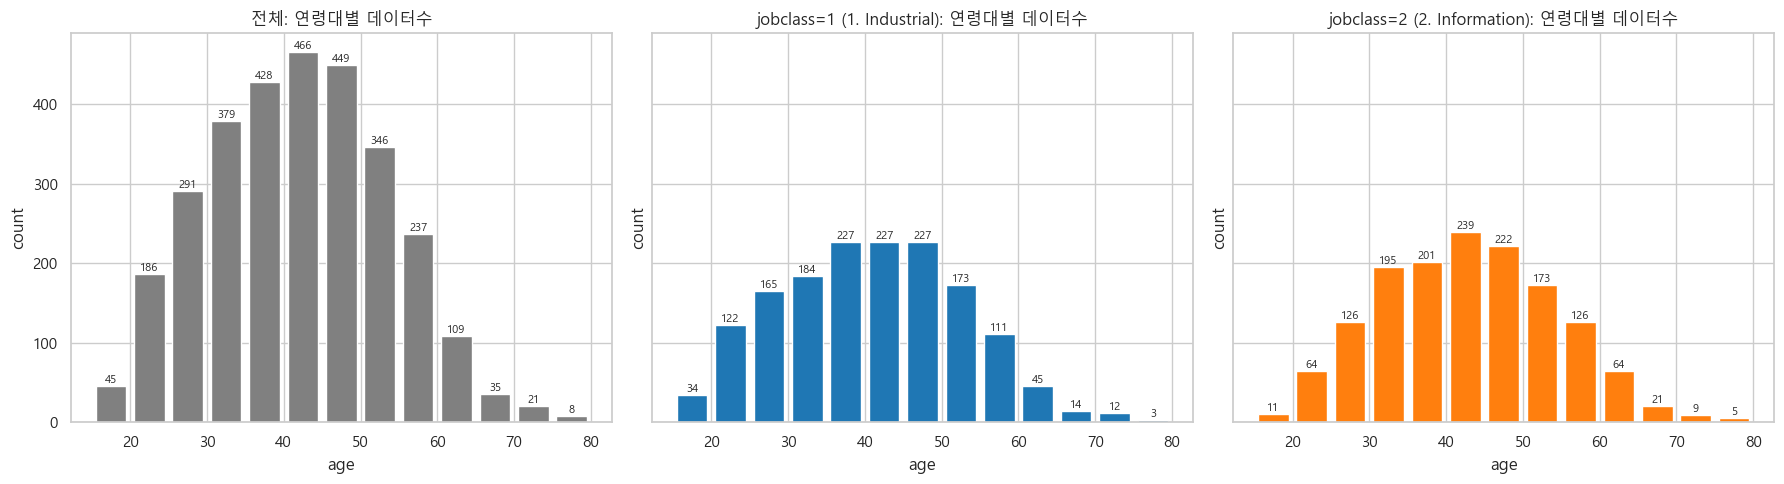

In [4]:
def age_count_panel(ax, data, title, color):
    """연령대별(5세 구간) 데이터 수 막대그래프"""
    cnt = data.groupby(pd.cut(data["age"], bins=bins), observed=False)["wage"].count()
    centers = [iv.mid for iv in cnt.index]
    ax.bar(centers, cnt.values, width=4, color=color, edgecolor="white")
    ax.set_title(title); ax.set_xlabel("age"); ax.set_ylabel("count")
    for x, v in zip(centers, cnt.values):          # 막대 위에 개수 표기
        ax.text(x, v, str(v), ha="center", va="bottom", fontsize=8)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
age_count_panel(axes[0], Wage, "전체: 연령대별 데이터수", "gray")          # job1, job2, bins는 위 셀에서 정의
age_count_panel(axes[1], job1, "jobclass=1 (1. Industrial): 연령대별 데이터수", "tab:blue")
age_count_panel(axes[2], job2, "jobclass=2 (2. Information): 연령대별 데이터수", "tab:orange")
plt.tight_layout(); plt.show()

표본은 **중년층(35~55세)에 집중**되어 있고, **청년층과 고령층(특히 70세 이상)은 매우 희박**하다.
이 표본 불균형이 이후 BNN 신용구간의 폭이 연령에 따라 달라지는 핵심 원인이 된다.

또한, jobclass=2인 "정보직"은 jobclass=1인 "생산직"보다 20세 전후 데이터 수가 절반 이하인 것을 볼 수 있으며, 이는 20세 전후의 신용구간 범위에 영향을 줄 수 있다.

## 4. 방법론

### 4.1 베이지안 신경망 모형

표준화된 연령 $x$ 에 대해 은닉층 2개(각 $H=16$, tanh)를 가진 신경망 $f_w(x)$ 로 임금을 모형화한다.

$$ y_i \mid w, \sigma \sim \mathcal{N}\!\big(f_w(x_i),\, \sigma^2\big), \qquad
f_w(x) = w_3^\top \tanh\!\big(W_2\,\tanh(w_1 x + b_1) + b_2\big) + b_3 . $$

가중치·절편에는 가우시안 사전분포 $w \sim \mathcal{N}(0, s^2)$, 잡음 표준편차에는 $\sigma \sim \text{HalfNormal}(1)$ 을
부여한다($s$ 는 가중치를 0으로 당기는 **수축(shrinkage)** 강도).

### 4.2 변분추론(SVI)과 ELBO

사후분포 $p(w, \sigma \mid \mathcal{D})$ 는 직접 계산이 불가능하므로, 다루기 쉬운 변분분포 $q_\lambda$(대각 정규근사)로
근사하고 **증거하한(ELBO)** 을 최대화한다. 구현은 NumPyro의 `AutoNormal` 가이드와 Adam 최적화를 사용한다.
비교를 위해 데이터는 표준화하고 학습/검증을 80:20으로 분할한다.

## 5. 모형 적합

### 5.1 일반 신경망 (MLE, 점추정)

먼저 동일 구조(은닉 16×2, tanh)의 신경망을 평균제곱오차 최소화로 학습한다.
가중치를 **단일 값**으로 추정하므로 예측은 하나의 곡선이며 불확실성 표현이 없다.

[일반 NN, MLE] test RMSE = 40.32


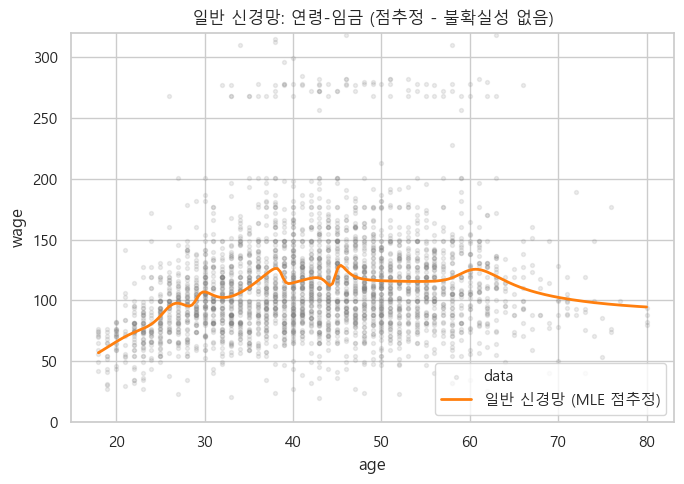

In [5]:
# 일반신경망으로 연령-임금 관계 모델링
import torch
import torch.nn as nn

# --- 공통 데이터 준비: 표준화 + 학습/검증 분할(80/20) (이후 BNN도 동일하게 사용) ---
age  = Wage["age"].to_numpy(float)
wage = Wage["wage"].to_numpy(float)

RNG = np.random.default_rng(0)
age_m, age_s = age.mean(), age.std()
wage_m, wage_s = wage.mean(), wage.std()
xz = (age - age_m) / age_s
yz = (wage - wage_m) / wage_s

n = len(Wage); idx = RNG.permutation(n); n_tr = int(0.8 * n)
tr, te = idx[:n_tr], idx[n_tr:]
x_tr, y_tr = xz[tr], yz[tr]
x_te, y_te = xz[te], yz[te]

age_grid = np.linspace(age.min(), age.max(), 200)
xg = (age_grid - age_m) / age_s
unz_y = lambda z: z * wage_s + wage_m   # 표준화 역변환

# --- 일반 신경망(MLE, 점추정): 은닉 16x2, tanh ---
torch.manual_seed(0)
net = nn.Sequential(nn.Linear(1, 16), nn.Tanh(),
                    nn.Linear(16, 16), nn.Tanh(),
                    nn.Linear(16, 1))
opt = torch.optim.Adam(net.parameters(), lr=1e-2)
lossf = nn.MSELoss()
Xtr_t = torch.tensor(x_tr, dtype=torch.float32).unsqueeze(1)
ytr_t = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1)
for ep in range(3000):
    opt.zero_grad(); loss = lossf(net(Xtr_t), ytr_t); loss.backward(); opt.step()

net.eval()
with torch.no_grad():
    nn_grid = unz_y(net(torch.tensor(xg,   dtype=torch.float32).unsqueeze(1)).squeeze(1).numpy())
    nn_te   =        net(torch.tensor(x_te, dtype=torch.float32).unsqueeze(1)).squeeze(1).numpy()
nn_rmse = np.sqrt(np.mean((unz_y(nn_te) - unz_y(y_te)) ** 2))
print(f"[일반 NN, MLE] test RMSE = {nn_rmse:.2f}")

# 시각화: 가중치를 단일 값으로 추정 -> 예측선 1개, 불확실성 표현 없음
plt.figure(figsize=(7, 5))
plt.scatter(age, wage, s=8, alpha=0.15, color="gray", label="data")
plt.plot(age_grid, nn_grid, color="tab:orange", lw=2, label="일반 신경망 (MLE 점추정)")
plt.title("일반 신경망: 연령-임금 (점추정 - 불확실성 없음)")
plt.xlabel("age"); plt.ylabel("wage"); plt.ylim(0, 320); plt.legend()
plt.tight_layout(); plt.show()

일반 신경망은 역U자 평균함수를 잡아내지만(검정 RMSE ≈ 40.3), 예측이 **선 하나**뿐이라
"이 예측을 얼마나 신뢰할 수 있는가"에는 답하지 못한다.

### 5.2 베이지안 신경망 (SVI)

같은 구조의 신경망 가중치에 사전분포를 부여하고 SVI로 사후분포를 근사한다.

In [6]:
# 베이지안 신경망으로 연령-임금 관계 모델링

In [7]:
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, Predictive
from numpyro.infer.autoguide import AutoNormal

numpyro.set_host_device_count(1)
# 데이터(x_tr, y_tr, x_te, y_te, xg, age_grid, unz_y)는 위 '일반신경망' 셀에서 준비한 것을 그대로 사용
print(f"train={len(x_tr)}  test={len(x_te)}")

train=2400  test=600


D:\python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
def bnn(x, y=None, H=16, prior_sd=1.0):
    x = x[:, None]; N, D = x.shape
    # 은닉층 1
    w1 = numpyro.sample("w1", dist.Normal(jnp.zeros((D, H)), prior_sd).to_event(2))
    b1 = numpyro.sample("b1", dist.Normal(jnp.zeros(H), prior_sd).to_event(1))
    z1 = jnp.tanh(x @ w1 + b1)
    # 은닉층 2
    w2 = numpyro.sample("w2", dist.Normal(jnp.zeros((H, H)), prior_sd).to_event(2))
    b2 = numpyro.sample("b2", dist.Normal(jnp.zeros(H), prior_sd).to_event(1))
    z2 = jnp.tanh(z1 @ w2 + b2)
    # 출력층
    w3 = numpyro.sample("w3", dist.Normal(jnp.zeros((H, 1)), prior_sd).to_event(2))
    b3 = numpyro.sample("b3", dist.Normal(0.0, prior_sd))
    mu = (z2 @ w3 + b3).squeeze(-1)
    numpyro.deterministic("mu", mu)
    sigma = numpyro.sample("sigma", dist.HalfNormal(1.0))
    with numpyro.plate("data", N):
        numpyro.sample("y", dist.Normal(mu, sigma), obs=y)

guide = AutoNormal(bnn)
svi = SVI(bnn, guide, numpyro.optim.Adam(5e-3), Trace_ELBO())
res = svi.run(jax.random.PRNGKey(0), 20000,
              jnp.array(x_tr), jnp.array(y_tr), prior_sd=1.0, progress_bar=False)
print(f"ELBO: start={float(res.losses[0]):.0f}  end={float(res.losses[-1]):.0f}")

ELBO: start=6666  end=3429


### 5.3 ELBO 수렴 진단

학습이 건전하게 진행되었는지 ELBO(증거하한)의 변화를 확인한다. ELBO가 단조로 **증가**하며 안정적으로
수렴하면(−ELBO는 감소), 최적화와 코드 정합성에 문제가 없다는 신호다.

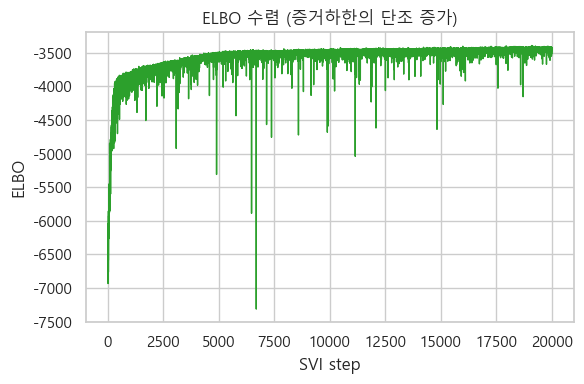

In [9]:
plt.figure(figsize=(6, 4))
plt.plot(-res.losses, lw=1, color="tab:green")
plt.xlabel("SVI step"); plt.ylabel("ELBO")
plt.title("ELBO 수렴 (증거하한의 단조 증가)")
plt.tight_layout(); plt.show()

ELBO가 약 $-6{,}666$ 에서 $-3{,}429$ 로 증가하며 안정적으로 수렴하였다.
수렴한 변분분포에서 사후예측 표본 1,000개를 생성해 평균함수와 불확실성을 추정한다.

### 5.4 사후예측과 불확실성

사후예측 분포로부터 **평균함수의 95% 신용구간**(모형 불확실성)과 잡음을 포함한 **95% 예측구간**을 계산한다.

In [10]:
pred = Predictive(bnn, guide=guide, params=res.params, num_samples=1000)
s = pred(jax.random.PRNGKey(1), jnp.array(xg), prior_sd=1.0)
mu_s, y_s = np.asarray(s["mu"]), np.asarray(s["y"])

bnn_mu = unz_y(mu_s.mean(0))
bnn_mu_lo, bnn_mu_hi = unz_y(np.percentile(mu_s, [2.5, 97.5], axis=0))  # 평균함수 신용구간
bnn_pp_lo, bnn_pp_hi = unz_y(np.percentile(y_s,  [2.5, 97.5], axis=0))  # 예측분포(잡음 포함)

s_te = pred(jax.random.PRNGKey(2), jnp.array(x_te), prior_sd=1.0)
bnn_rmse = np.sqrt(np.mean((unz_y(np.asarray(s_te["mu"]).mean(0)) - unz_y(y_te)) ** 2))
print(f"[BNN SVI] test RMSE = {bnn_rmse:.2f}")

[BNN SVI] test RMSE = 40.26


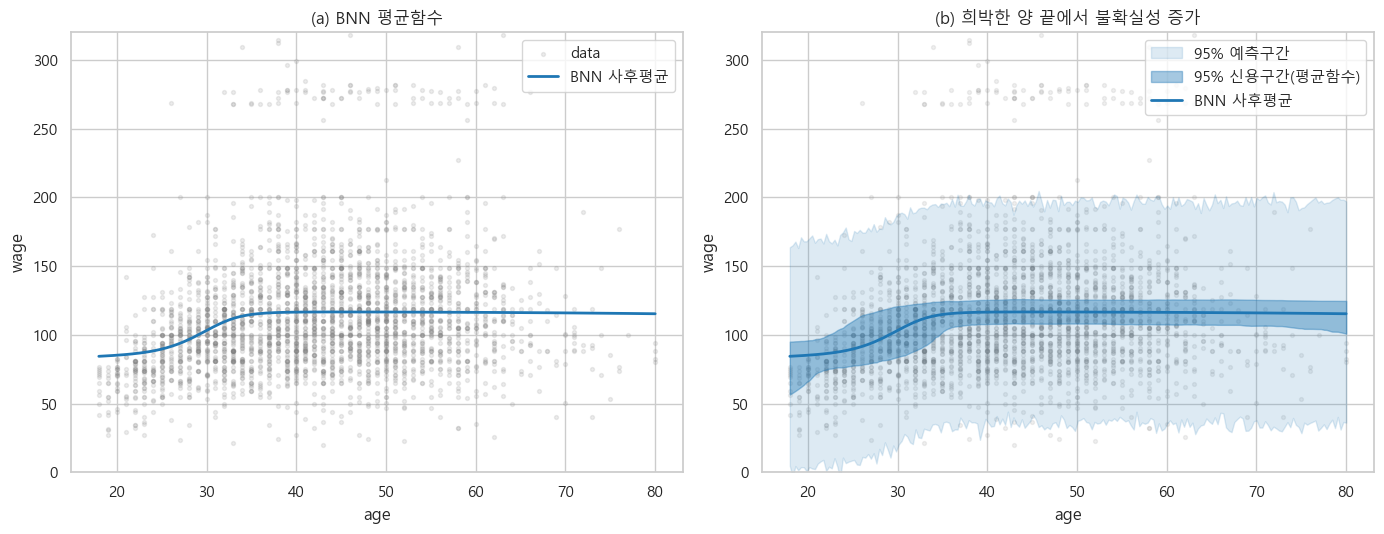

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))

ax[0].scatter(age, wage, s=8, alpha=0.15, color="gray", label="data")
ax[0].plot(age_grid, bnn_mu, color="tab:blue", lw=2, label="BNN 사후평균")
ax[0].set_title("(a) BNN 평균함수"); ax[0].set_xlabel("age")
ax[0].set_ylabel("wage"); ax[0].set_ylim(0, 320); ax[0].legend()

ax[1].scatter(age, wage, s=8, alpha=0.12, color="gray")
ax[1].fill_between(age_grid, bnn_pp_lo, bnn_pp_hi, color="tab:blue", alpha=0.15, label="95% 예측구간")
ax[1].fill_between(age_grid, bnn_mu_lo, bnn_mu_hi, color="tab:blue", alpha=0.40, label="95% 신용구간(평균함수)")
ax[1].plot(age_grid, bnn_mu, color="tab:blue", lw=2, label="BNN 사후평균")
ax[1].set_title("(b) 희박한 양 끝에서 불확실성 증가"); ax[1].set_xlabel("age")
ax[1].set_ylabel("wage"); ax[1].set_ylim(0, 320); ax[1].legend()
plt.tight_layout(); plt.show()

(a) BNN 사후평균은 역U자를 재현한다. (b) **신용구간은 데이터가 풍부한 중년 구간에서 좁고,
표본이 희박한 청년·고령 구간에서 넓어진다.** 즉 BNN은 외삽 위험이 큰 구간에서 불확실성을 정직하게 키운다.
일반 신경망과 검정 RMSE는 거의 같지만(≈40), 이처럼 **불확실성을 표현**한다는 점이 본질적 차이다.

## 6. 직군(jobclass)별 비교

연령 단독 모형을 직군별로 나누어 반복하여, 직군에 따라 적합도·불확실성이 어떻게 달라지는지 본다.

jobclass=1(`1. Industrial`)과 jobclass=2(`2. Information`)로 나누어, 앞과 동일하게 일반 NN·BNN을 적합한다.

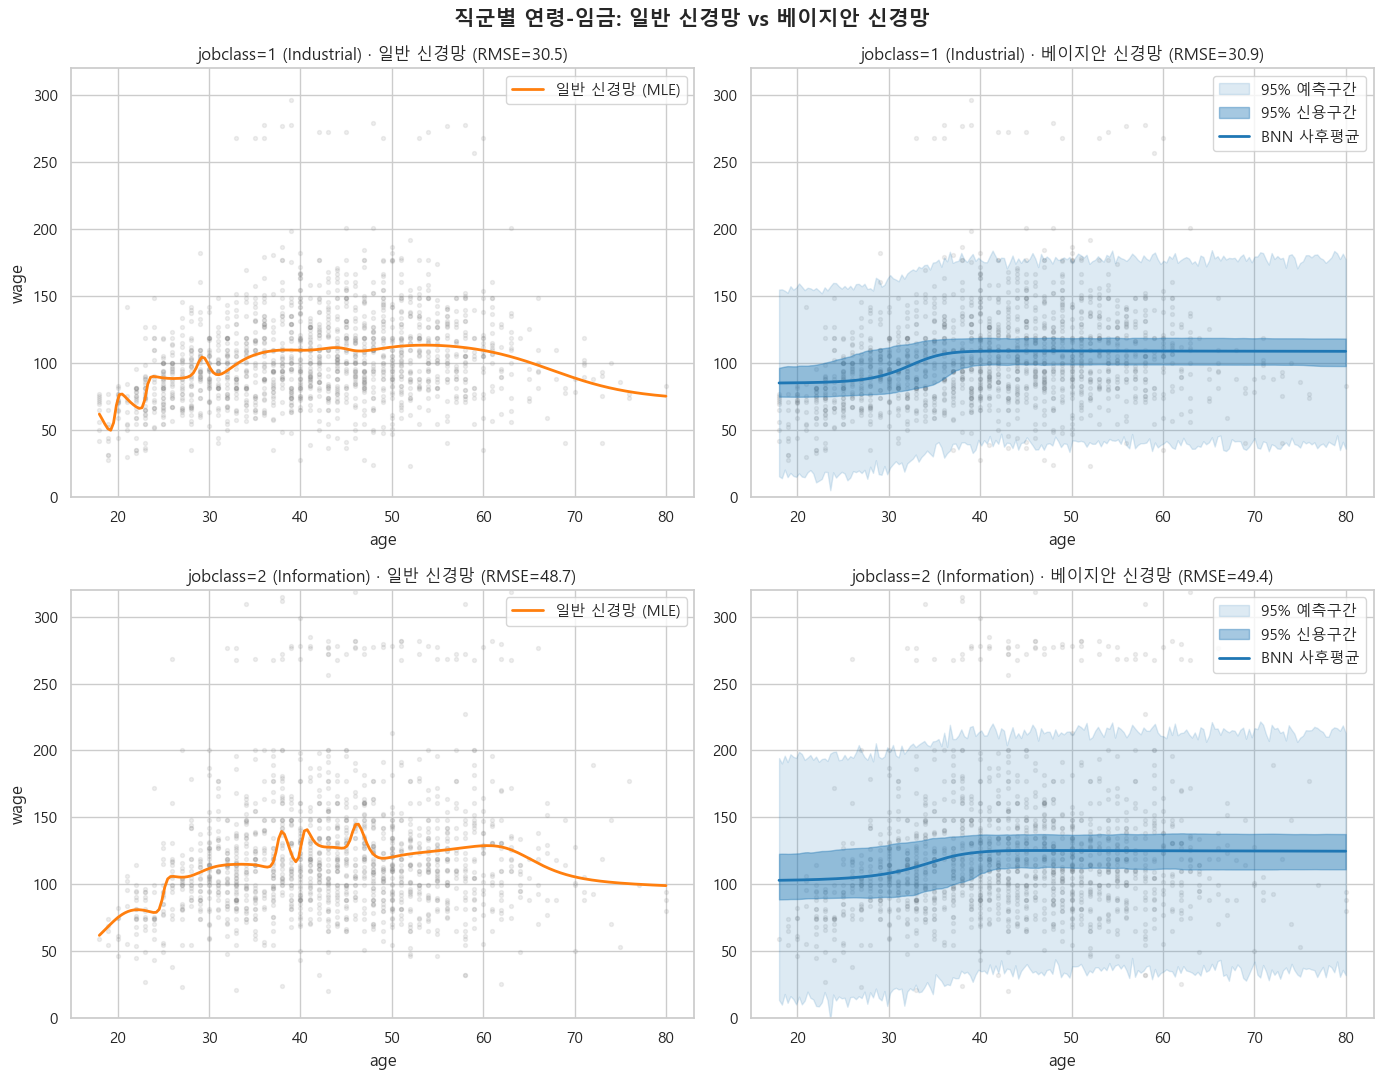

In [12]:
def fit_group(jobclass_value):
    """한 직군에 대해 일반NN + BNN을 적합하고 시각화·RMSE 값을 반환"""
    sub = Wage[Wage["jobclass"] == jobclass_value]
    ag = sub["age"].to_numpy(float); wg = sub["wage"].to_numpy(float)
    rng = np.random.default_rng(0)
    am, asd = ag.mean(), ag.std(); wm, wsd = wg.mean(), wg.std()
    xz = (ag-am)/asd; yz = (wg-wm)/wsd
    m = len(sub); ix = rng.permutation(m); k = int(0.8*m)
    xtr, ytr = xz[ix[:k]], yz[ix[:k]]; xte, yte = xz[ix[k:]], yz[ix[k:]]
    grid = np.linspace(ag.min(), ag.max(), 200); xg = (grid-am)/asd
    unz = lambda z: z*wsd + wm

    # 일반 신경망 (MLE, 점추정)
    torch.manual_seed(0)
    net = nn.Sequential(nn.Linear(1,16), nn.Tanh(), nn.Linear(16,16), nn.Tanh(), nn.Linear(16,1))
    opt = torch.optim.Adam(net.parameters(), lr=1e-2); lf = nn.MSELoss()
    Xt = torch.tensor(xtr, dtype=torch.float32).unsqueeze(1)
    yt = torch.tensor(ytr, dtype=torch.float32).unsqueeze(1)
    for _ in range(3000):
        opt.zero_grad(); l = lf(net(Xt), yt); l.backward(); opt.step()
    net.eval()
    with torch.no_grad():
        nn_grid = unz(net(torch.tensor(xg,  dtype=torch.float32).unsqueeze(1)).squeeze(1).numpy())
        nn_te   =     net(torch.tensor(xte, dtype=torch.float32).unsqueeze(1)).squeeze(1).numpy()
    nn_rmse_g = np.sqrt(np.mean((unz(nn_te)-unz(yte))**2))

    # 베이지안 신경망 (SVI): 기존 bnn 재사용
    g = AutoNormal(bnn); svi = SVI(bnn, g, numpyro.optim.Adam(5e-3), Trace_ELBO())
    r = svi.run(jax.random.PRNGKey(0), 20000, jnp.array(xtr), jnp.array(ytr), prior_sd=1.0, progress_bar=False)
    pr = Predictive(bnn, guide=g, params=r.params, num_samples=1000)
    sg = pr(jax.random.PRNGKey(1), jnp.array(xg), prior_sd=1.0)
    mu = unz(np.asarray(sg["mu"]).mean(0))
    mlo, mhi = unz(np.percentile(np.asarray(sg["mu"]), [2.5,97.5], axis=0))
    plo, phi = unz(np.percentile(np.asarray(sg["y"]),  [2.5,97.5], axis=0))
    st = pr(jax.random.PRNGKey(2), jnp.array(xte), prior_sd=1.0)
    bnn_rmse_g = np.sqrt(np.mean((unz(np.asarray(st["mu"]).mean(0))-unz(yte))**2))
    return dict(ag=ag, wg=wg, grid=grid, nn_grid=nn_grid, mu=mu, mlo=mlo, mhi=mhi,
                plo=plo, phi=phi, nn_rmse=nn_rmse_g, bnn_rmse=bnn_rmse_g, n=m)

groups = [("1. Industrial",  "jobclass=1 (Industrial)"),
          ("2. Information", "jobclass=2 (Information)")]
R = {lab: fit_group(val) for val, lab in groups}

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for row, (val, lab) in enumerate(groups):
    d = R[lab]; a0, a1 = axes[row, 0], axes[row, 1]
    a0.scatter(d["ag"], d["wg"], s=8, alpha=0.13, color="gray")
    a0.plot(d["grid"], d["nn_grid"], color="tab:orange", lw=2, label="일반 신경망 (MLE)")
    a0.set_title(f"{lab} · 일반 신경망 (RMSE={d['nn_rmse']:.1f})")
    a0.set_xlabel("age"); a0.set_ylabel("wage"); a0.set_ylim(0,320); a0.legend()
    a1.scatter(d["ag"], d["wg"], s=8, alpha=0.13, color="gray")
    a1.fill_between(d["grid"], d["plo"], d["phi"], color="tab:blue", alpha=0.15, label="95% 예측구간")
    a1.fill_between(d["grid"], d["mlo"], d["mhi"], color="tab:blue", alpha=0.40, label="95% 신용구간")
    a1.plot(d["grid"], d["mu"], color="tab:blue", lw=2, label="BNN 사후평균")
    a1.set_title(f"{lab} · 베이지안 신경망 (RMSE={d['bnn_rmse']:.1f})")
    a1.set_xlabel("age"); a1.set_ylim(0,320); a1.legend()
fig.suptitle("직군별 연령-임금: 일반 신경망 vs 베이지안 신경망", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.show()

**Industrial** 직군은 임금 분산이 작아 RMSE가 낮고(≈31), **Information** 직군은 고소득 군집으로
분산이 커 RMSE가 높다(≈49). 어느 직군에서도 일반 NN과 BNN의 평균 정확도는 비슷하며, BNN의 예측구간 폭이
분산이 큰 Information에서 더 넓게 나타난다.

## 7. 종합 결과 (test RMSE 요약)

In [13]:
# ===== 전체 RMSE 요약 =====
print("=" * 50)
print(f"{'데이터':<26}{'일반NN':>9}{'BNN':>9}")
print("-" * 50)
print(f"{'전체 (n=%d)' % n:<26}{nn_rmse:>9.2f}{bnn_rmse:>9.2f}")
for val, lab in groups:
    d = R[lab]
    print(f"{'%s (n=%d)' % (lab, d['n']):<26}{d['nn_rmse']:>9.2f}{d['bnn_rmse']:>9.2f}")
print("=" * 50)

데이터                            일반NN      BNN
--------------------------------------------------
전체 (n=3000)                   40.32    40.26
jobclass=1 (Industrial) (n=1544)    30.53    30.93
jobclass=2 (Information) (n=1456)    48.70    49.43


모든 경우에서 일반 신경망과 BNN의 RMSE는 거의 동일하다. 이는 연령 단독으로 설명되는 임금 변동이
제한적이고(임금의 이질성), 두 모형이 같은 역U자 평균함수를 잡아내기 때문이다. 이 사례에서 BNN의 가치는
점예측 정확도가 아니라 **불확실성의 표현**에 있다.

## 8. 결론

연령–임금 비선형 회귀에서 일반 신경망과 베이지안 신경망을 비교한 결과, 평균 예측은 유사했으나
**불확실성 표현에서 결정적 차이**가 드러났다. BNN은 가중치를 분포로 두고 SVI로 사후분포를 근사함으로써,
데이터가 풍부한 중년층에서는 좁고 희박한 청년·고령층에서는 넓은 신용구간을 제공했다. 이는 예측의 신뢰도를
정량화해야 하는 실무(정책·의사결정)에서 베이지안 접근이 갖는 본질적 이점이다.